In [1]:
import os, sys
from pathlib import Path

os.chdir(next(p for p in Path.cwd().parents if (p / 'src').exists()))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

In [2]:
import time
import tensorflow as tf
import numpy as np
import random

from src.networks.DecoderPINN import PINN
from src.networks.Encoder import Encoder
from src.optimization.EncoderTrainer import EncoderTrainer
from src.data.encoder_dataloader import load_encoder_data
from src.visualization.historyplots import plot_encoder_adam_history, plot_encoder_terms
from src.hyperparameters import hypers_uqvae as h

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

2026-10-03 15:55:38.501774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791035738.510382   86966 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791035738.513140   86966 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791035738.520357   86966 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791035738.520370   86966 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791035738.520372   86966 computation_placer.cc:177] computation placer alr

In [3]:
output_dir = 'models/pipeline_evolution/04_uq-vae'
results_dir = 'results/pipeline_evolution/04_uq-vae'
decoder_dir = 'models/pipeline_evolution/03_parametric_pinn'
data_dir = 'data/parametric/400x400'

os.makedirs(output_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

train_path = os.path.join(data_dir, 'train.npz')
val_path = os.path.join(data_dir, 'val.npz')
test_path = os.path.join(data_dir, 'test.npz')
scale_path = os.path.join(data_dir, 'u_scale.npy')
base_data_dir = os.path.dirname(data_dir)
sensor_idx_path = os.path.join(base_data_dir, 'sensor_idx.npy')

(y_train_clean, u_train), (y_obs_val, u_val), (y_obs_test, u_test), X_obs, sensor_idx, U_SCALE = load_encoder_data(
    train_path=train_path, val_path=val_path, test_path=test_path,
    scale_path=scale_path, n_sensors=h.N_SENSORS,
    region_bounds=h.SENSOR_REGION, sensor_idx_path=sensor_idx_path,
    noise_level=h.NOISE, dtype=number_type
)

noise_global_path = os.path.join(base_data_dir, 'noise.npz')
sigma_noise = float(np.load(noise_global_path)['noise_std_physical']) / float(U_SCALE)
print(f"sigma_noise (scaled): {sigma_noise:.5f}")

[SENSORS] Used sensors saved in: data/parametric/sensor_idx.npy
Shape y_train: (799, 200)  |  Shape u_train: (799, 2)
Shape y_val:   (99, 200)  |  Shape u_val:   (99, 2)
Shape y_test:  (101, 200)  |  Shape u_test:  (101, 2)
sigma_noise (scaled): 0.01957


I0000 00:00:1791035741.068147   86966 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [4]:
decoder_pinn = PINN(h.N_NEURONS_DECODER, U_SCALE)
decoder_pinn(tf.zeros((1, 4)))
decoder_weights_path = os.path.join(decoder_dir, 'decoder_lbfgs.weights.h5')
if not os.path.exists(decoder_weights_path):
    decoder_weights_path = os.path.join(decoder_dir, 'decoder_adam.weights.h5')
decoder_pinn.load_weights(decoder_weights_path)
print(f"Decoder weights loaded: {decoder_weights_path}")

decoder_pinn.trainable = False

Decoder weights loaded: models/pipeline_evolution/03_parametric_pinn/decoder_lbfgs.weights.h5


In [5]:
encoder = Encoder(n_neurons=h.N_NEURONS_ENCODER, latent_dim=h.D_z)
encoder(tf.zeros((1, h.N_SENSORS)))
encoder.init_output_layer(bias=h.BIAS, weight_scale=h.WEIGHT_SCALE_ENCODER_OUT)

# Optimizer
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    h.LR_ENCODER,
    decay_steps=h.LR_DECAY_STEPS_ENCODER,
    decay_rate=h.LR_DECAY_RATE_ENCODER,
    staircase=False
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, epsilon=1e-12)
optimizer.build(encoder.trainable_variables)

In [6]:
mu_pr = tf.constant(h.MU_PR, dtype=number_type)
sigma_pr = tf.constant(h.SIGMA_PR, dtype=number_type)
Gamma_pr = tf.eye(h.D_z, dtype=number_type) * (sigma_pr ** 2)
Gamma_pr_inv = tf.linalg.inv(Gamma_pr)
B_train = tf.shape(u_train)[0]
D_y = tf.shape(X_obs)[0]

x_obs_exp = tf.tile(X_obs[tf.newaxis, :, :], [B_train, 1, 1])
u_exp = tf.tile(u_train[:, tf.newaxis, :], [1, D_y, 1])
pinn_in = tf.concat([x_obs_exp, u_exp], axis=-1)
pinn_in_flat = tf.reshape(pinn_in, [-1, 4])

y_pred_flat = decoder_pinn(pinn_in_flat)
y_pred = tf.reshape(y_pred_flat, [B_train, D_y])

residuals_clean = y_train_clean - y_pred
mu_dec = tf.reduce_mean(residuals_clean, axis=0)

residuals_centered = residuals_clean - mu_dec
Gamma_decoder = tf.matmul(residuals_centered, residuals_centered, transpose_a=True) / tf.cast(B_train - 1, number_type)

sigma_noise_tf = tf.constant(sigma_noise, dtype=number_type)
Gamma_noise = tf.square(sigma_noise_tf) * tf.eye(D_y, dtype=number_type)

Gamma_E = Gamma_decoder + Gamma_noise
Gamma_E_inv = tf.linalg.inv(Gamma_E)

mu_E = mu_dec

gamma_save_path = os.path.join(output_dir, 'gamma_E.npz')
np.savez(gamma_save_path, mu_E=mu_E.numpy(), Gamma_E_inv=Gamma_E_inv.numpy())

I0000 00:00:1791035743.317402   86966 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x641b41f47820


In [7]:
@tf.function
def augment(y, u):
    if h.NOISE > 0.0:
        noise = tf.random.normal(shape=tf.shape(y), mean=0.0, stddev=sigma_noise, dtype=number_type)
        y_noisy = y + noise
    else:
        y_noisy = y
    return y_noisy, u

train_dataset = (
    tf.data.Dataset.from_tensor_slices((y_train_clean, u_train))
    .shuffle(buffer_size=10000, seed=42)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(h.BATCH_SIZE_ENCODER, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE))

In [8]:
t0_enc = time.time()
trainer = EncoderTrainer(encoder=encoder, decoder=decoder_pinn, output_dir=output_dir, result_dir=results_dir)
trainer.train_adam(optimizer=optimizer, epochs=h.EPOCHS_ENCODER_ADAM,
                   train_dataset=train_dataset,
                   y_obs_val=y_obs_val,
                   x_obs=X_obs,
                   mu_pr=mu_pr, Gamma_pr=Gamma_pr, Gamma_pr_inv=Gamma_pr_inv,
                   mu_E=mu_E,
                   Gamma_E_inv=Gamma_E_inv,
                   theta=h.THETA_ENCODER,
                   patience=h.PATIENCE_ENCODER_ADAM,
                   save_freq=h.SAVE_FREQ_ENCODER_ADAM,
                   dtype=number_type)
t_enc = time.time() - t0_enc

print(f"Encoder training time: {t_enc:.1f} s")



Starting Encoder Adam optimization...


I0000 00:00:1791035744.870474   86966 service.cc:152] XLA service 0x641b5a439120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791035744.870517   86966 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1791035745.314976   86966 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1791035746.500139   86966 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch    0 | Loss: 1.8648e+03 | Val Loss: 1.5249e+03
   train: prior_trace_inv: 2.289e-06 | prior_mean: 5.448e-02 | prior_trace: 1.787e-06 | data_mean: 1.865e+03 | data_trace: 1.001e-02
   val:   prior_trace_inv: 2.513e-06 | prior_mean: 7.671e-02 | prior_trace: 1.600e-06 | data_mean: 1.525e+03 | data_trace: 6.891e-04
Epoch  100 | Loss: 3.1374e+02 | Val Loss: 2.9206e+02
   train: prior_trace_inv: 1.363e-04 | prior_mean: 1.251e+00 | prior_trace: 5.520e-08 | data_mean: 3.125e+02 | data_trace: 4.214e-04
   val:   prior_trace_inv: 1.082e-04 | prior_mean: 7.050e-01 | prior_trace: 6.848e-08 | data_mean: 2.914e+02 | data_trace: 4.344e-04
Epoch  200 | Loss: 2.4114e+02 | Val Loss: 2.6586e+02
   train: prior_trace_inv: 1.432e-04 | prior_mean: 1.124e+00 | prior_trace: 5.813e-08 | data_mean: 2.400e+02 | data_trace: 3.291e-04
   val:   prior_trace_inv: 1.569e-04 | prior_mean: 1.626e+00 | prior_trace: 4.858e-08 | data_mean: 2.642e+02 | data_trace: 2.332e-04
Epoch  300 | Loss: 2.4309e+02 | Val Loss: 2

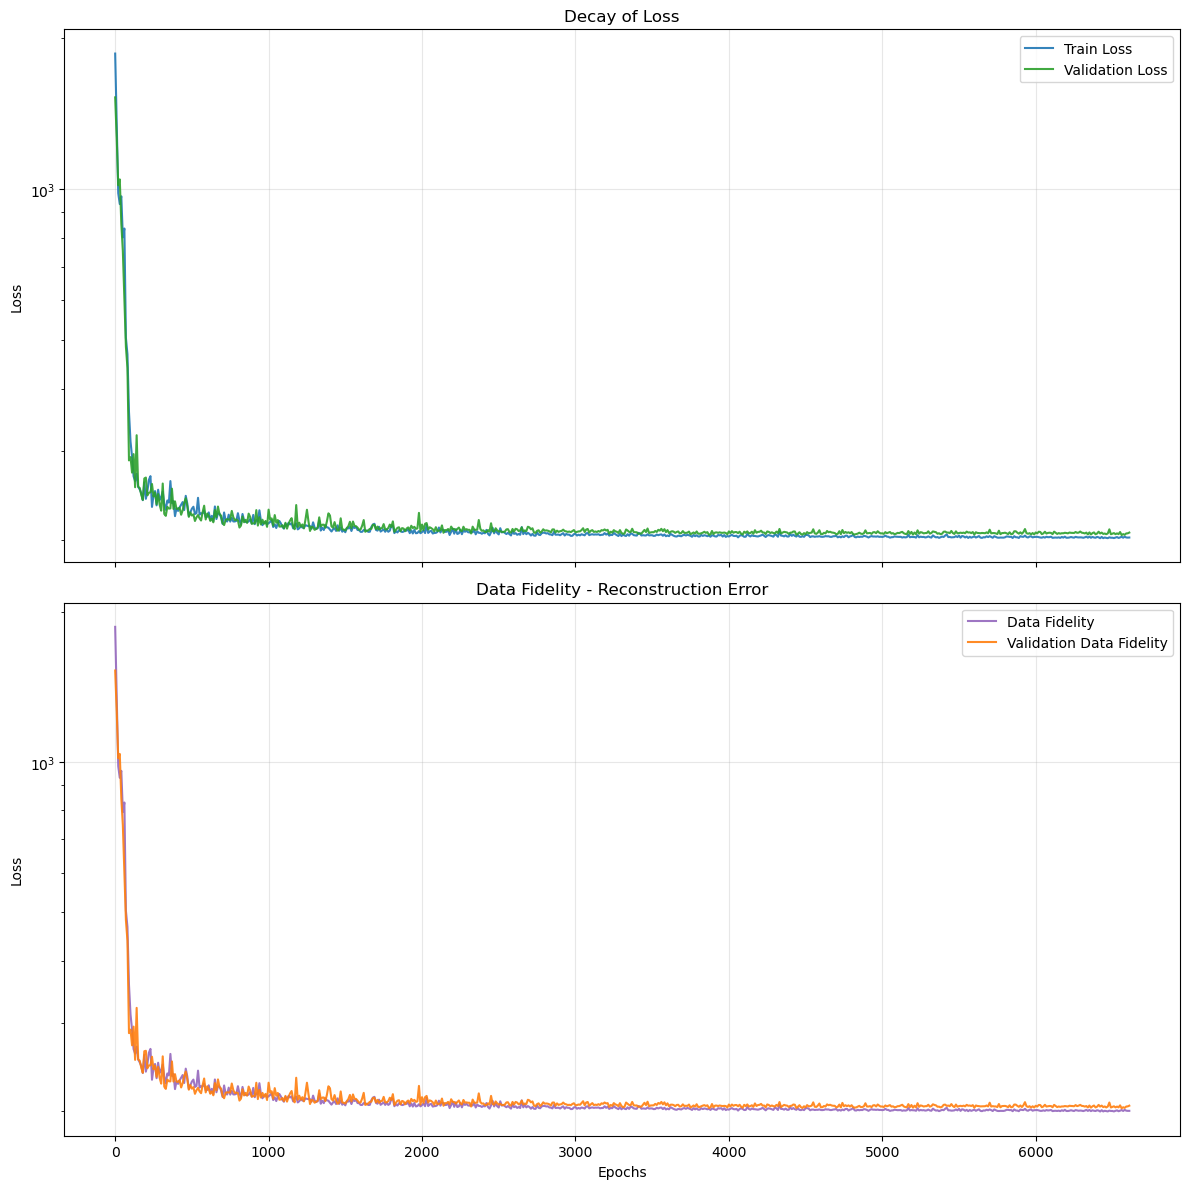

In [9]:
history_adam_path = os.path.join(results_dir, 'encoder_adam.loss.npz')
np.savez(history_adam_path, **trainer.history_adam)
plot_encoder_adam_history(trainer.history_adam, save_freq=h.SAVE_FREQ_ENCODER_ADAM)

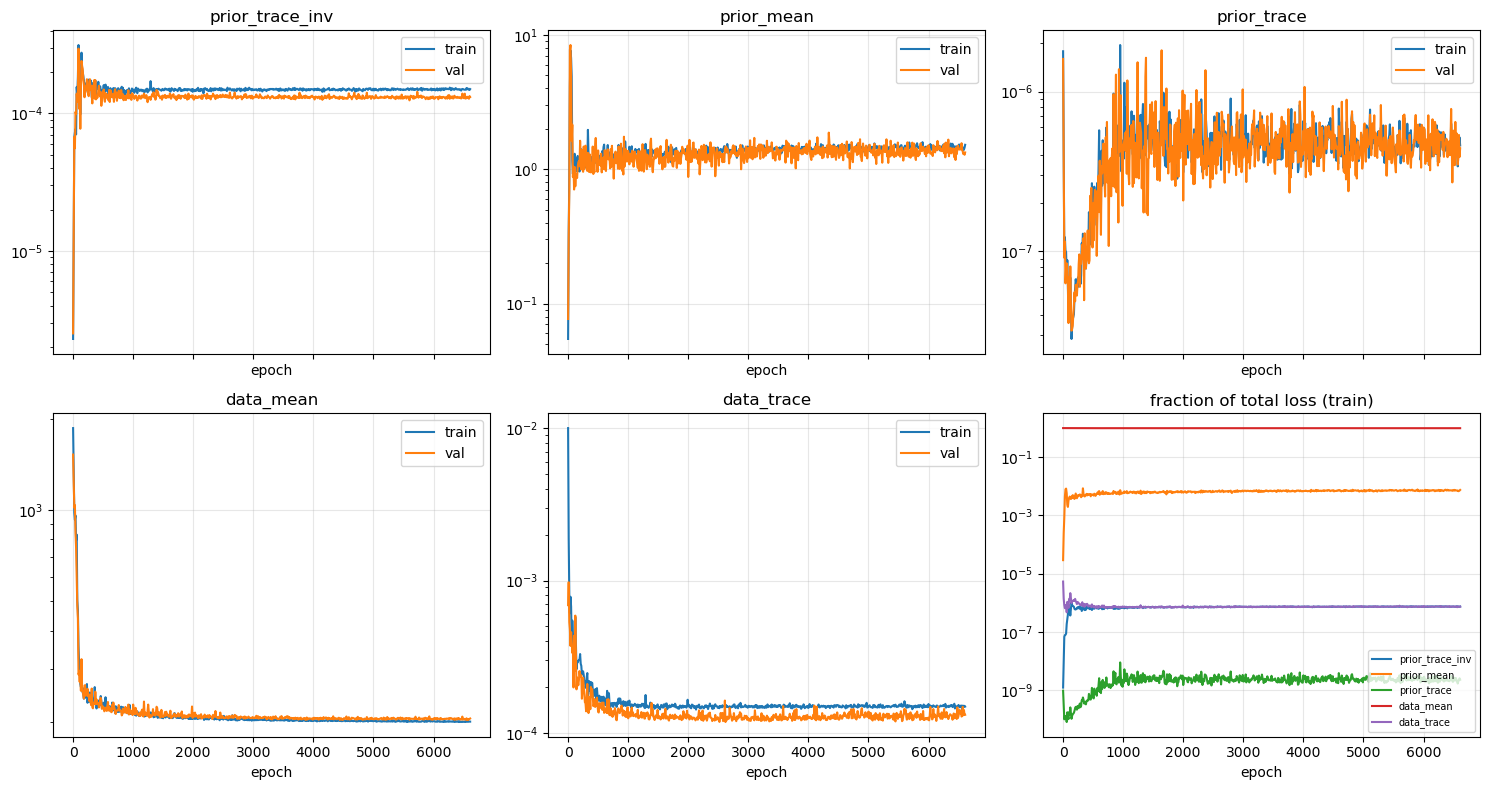

In [10]:
plot_encoder_terms(trainer.history_adam, save_freq=h.SAVE_FREQ_ENCODER_ADAM)

In [11]:
qz_val = encoder(y_obs_val)
u_pred_val = qz_val.mean().numpy()

mae_u_val = np.mean(np.abs(u_pred_val - u_val.numpy()), axis=0)
print(f"MAE Validation on cx: {mae_u_val[0]:.4f}")
print(f"MAE Validation on cy: {mae_u_val[1]:.4f}\n")

print("True vs Pred (first 5 samples Validation):")
for i in range(min(5, len(u_val))):
    print(f"True [cx, cy]: {u_val[i].numpy()} | Pred [cx, cy]: {u_pred_val[i]}")

MAE Validation on cx: 0.0624
MAE Validation on cy: 0.0732

True vs Pred (first 5 samples Validation):
True [cx, cy]: [0.215      0.66799998] | Pred [cx, cy]: [0.41247338 0.5954422 ]
True [cx, cy]: [0.32300001 0.75099999] | Pred [cx, cy]: [0.35588455 0.7099664 ]
True [cx, cy]: [0.28200001 0.66799998] | Pred [cx, cy]: [0.38135114 0.6724673 ]
True [cx, cy]: [0.51800001 0.38100001] | Pred [cx, cy]: [0.59702516 0.36891726]
True [cx, cy]: [0.68599999 0.61699998] | Pred [cx, cy]: [0.68597925 0.6174219 ]


In [12]:
qz_test = encoder(y_obs_test)
u_pred_test = qz_test.mean().numpy()

mae_u_test = np.mean(np.abs(u_pred_test - u_test.numpy()), axis=0)
mae_cx_test = float(mae_u_test[0])
mae_cy_test = float(mae_u_test[1])    
print(f"\nMAE Test on cx: {mae_cx_test:.4f}")
print(f"MAE Test on cy: {mae_cy_test:.4f}")

mu = tf.cast(qz_test.mean(), number_type)            
cov = tf.cast(qz_test.covariance(), number_type)    
diff = u_test - mu    
inv_cov = tf.linalg.inv(cov) 

mahalanobis_sq = tf.einsum('ni,nij,nj->n', diff, inv_cov, diff)
coverage_2d_68 = tf.reduce_mean(tf.cast(mahalanobis_sq <= 2.296, tf.float32)) * 100.0
coverage_2d_95 = tf.reduce_mean(tf.cast(mahalanobis_sq <= 5.991, tf.float32)) * 100.0
coverage_2d_68_val = float(coverage_2d_68.numpy())
coverage_2d_95_val = float(coverage_2d_95.numpy())
print(f"Coverage (target 68.3%): {coverage_2d_68_val:.2f}%")
print(f"Coverage (target 95.0%): {coverage_2d_95_val:.2f}%")



MAE Test on cx: 0.0624
MAE Test on cy: 0.0587
Coverage (target 68.3%): 71.29%
Coverage (target 95.0%): 90.10%
